In [ ]:
# 12 January 2026
# Zachary Katz
# zachary_katz@mines.edu

"""
Load offset video KRT2 radar over Subglacial Lake Cheongsuk [David Glacier]
Hilbert transform to complex space and compute doppler spectra
Pick width and maximum frequency and plot in map view
"""

import os

import numpy as np
import scipy
from scipy.signal import hilbert
from scipy.ndimage import gaussian_filter
from skimage import feature, filters
from skimage.filters import sato
from scipy.signal.windows import hann

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import cartopy.crs as ccrs

import segyio
import shapefile
import shapely
import xarray as xr

%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
# Load utig netcdf files
utig_path = './_data/UTG_Complex'
file_paths = [os.path.join(utig_path, f) for f in os.listdir(utig_path) if f.endswith('.nc')]

utig_radargrams = []
for f in file_paths[:]:
    utig_radargram = xr.open_dataset(f)
    utig_radargrams.append(utig_radargram)


/tmp/ipykernel_20837/842517954.py:7: FutureWarning: In a future version, xarray will not decode the variable 'fast_time' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  utig_radargram = xr.open_dataset(f)
/tmp/ipykernel_20837/842517954.py:7: FutureWarning: In a future version, xarray will not decode the variable 'fast_time' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To con

In [3]:
utig_radargrams.sort(key=lambda x: x.transect_id)
utig_radargrams[0]

<xarray.Dataset> Size: 899MB
Dimensions:    (distance: 23382, fast_time: 3200)
Coordinates:
  * distance   (distance) float64 187kB 0.0 1.0 2.0 ... 2.338e+04 2.338e+04
  * fast_time  (fast_time) timedelta64[ns] 26kB 00:00:00 ... 00:00:00.000063980
Data variables:
    x          (distance) float64 187kB ...
    y          (distance) float64 187kB ...
    h          (distance) float64 187kB ...
    time       (distance) datetime64[ns] 187kB ...
    bxds7      (distance, fast_time) int16 150MB ...
    bxds6      (distance, fast_time) int16 150MB ...
    bxds5      (distance, fast_time) int16 150MB ...
    bxds1      (distance, fast_time) int16 150MB ...
    bxds8      (distance, fast_time) int16 150MB ...
    bxds2      (distance, fast_time) int16 150MB ...
Attributes: (12/13)
    transect_id:     D2DG/IBH0e/X10a
    history:         Created on Sun Jan  4 16:46:26 2026 by Duncan A. Young
    funding:         KOPRI/K-ROUTE
    expedition:      KRT2
    platform:        AS-350 helicopter
    radar:           HeRa
    ...              ...
    sample_rate_hz:  50000000.0
    chirp_start_hz:  17500000.0
    chirp_end_hz:    2500000.0
    lo_gain_dbm:     82.7
    high_gain_dbm:   128.7
    reference:       http://doi.org/10.26153/tsw/11620

In [4]:
# Load Lake Cheongsuk shapefile
sld_path = '/mnt/c/Users/ZacharyKatz/Desktop/Research/_Semesters/25FA/KOPRI/SLD2'
pathA = sld_path + '/SLD2-A.shp'
pathB = sld_path + '/SLD2-B.shp'
pathC = sld_path + '/SLD2-C.shp'

xs_lake = []
ys_lake = []
for path in [pathA, pathB, pathC]:
    sf = shapefile.Reader(path)
    shapes = sf.shapes()
    for shp in shapes:
        points = shp.points
        x = [p[0] for p in points]
        y = [p[1] for p in points]
    xs_lake.append(x)
    ys_lake.append(y)


In [301]:
# Set up plan view plotting function
def plot_radargram_planview(ax, radargrams, xs_lake, ys_lake):
    bbox = [650000,-1475000,680000,-1430000] #David_SGL2_full

    ax.patch.set_facecolor("none")
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])

    for radargram in utig_radargrams[:]:
        #ax.plot(radargram.x, radargram.y, color='gray', zorder=3, transform=ps71_projection,linewidth=1)
        #print(radargram.transect_id.split('/')[-1])
        ax.text(radargram.x[0], radargram.y[0], radargram.transect_id.split('/')[-1], color='black', fontsize=10, transform=ps71_projection, zorder=5)

    for x, y in zip(xs_lake, ys_lake):
        ax.plot(x, y, color='black', linewidth=3, zorder=0)

    ax.set_xlim(bbox[0],bbox[2])
    ax.set_ylim(bbox[1],bbox[3])



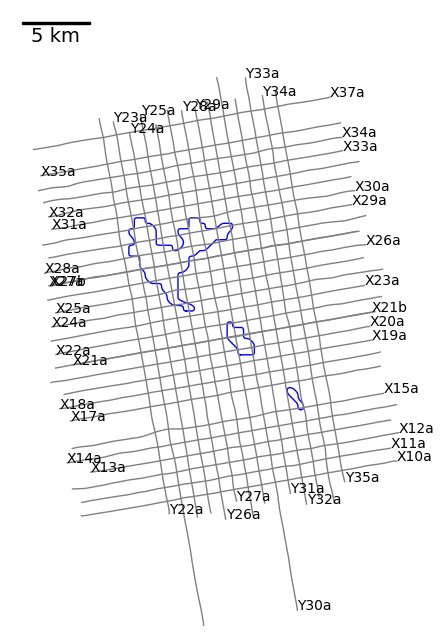

In [6]:
# Plot plan view comparison
ps71_projection = ccrs.Stereographic(central_latitude=-90, central_longitude=0, true_scale_latitude=-71)
fig, ax = plt.subplots(figsize=(8,8), subplot_kw={'projection': ps71_projection})

plot_radargram_planview(ax, utig_radargrams, xs_lake, ys_lake)
scalebar = AnchoredSizeBar(ax.transData, 5000, '5 km', 'upper left', 
                           pad=0.5, color='black', frameon=False, size_vertical=200, fontproperties={'size': 14})
ax.add_artist(scalebar)


In [249]:
# Functions for calculating and interperting doppler spectra
def plot_hilbert_transform(radargram, data):
    vmin = -80
    vmax = 0

    eps = 1e-20
    amp = np.abs(data)  
    amp = amp / np.max(amp)
    rad_db = 20 * np.log10(amp + eps)
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    im = ax.imshow(rad_db,aspect='auto',cmap='gray',vmin=vmin,vmax=vmax)

    cb = fig.colorbar(im, ax=ax, label="Amplitude [dB]")
    ax.set_ylabel("Fast time [ns]",fontsize=16)
    ax.set_xlabel("Along Track Distance [m]",fontsize=16)
    ax.tick_params(labelsize=14)
    cb.ax.tick_params(labelsize=14)
    cb.set_label("Relative Return [dB]", fontsize=16)

def compute_doppler_spectrum(radargram, data):
    """
    Compute doppler spectrum of radargram using hilbert transform.

    Parameters
    ----------
    radargram : Xarray.Dataframe
        UTIG radargram offset video

    Returns
    -------
    doppler_spectrum : np.ndarray
        2D array of doppler spectrum 
    """
    
    start_y = 1200
    end_y = 1800
    start_x = 17500
    end_x = 18000

    data_for_fft = data[start_y:end_y:,start_x:end_x]
    data_fft = np.fft.fftshift(np.fft.fft(data_for_fft, axis=1), axes=1)

    # Make freq axis
    t = utig_radargram['time'] 
    t_sec = (t - t[0]).astype('timedelta64[ns]').astype(np.float64) * 1e-9
    dt_slow = np.median(np.diff(t_sec.compute()))
    n_slow = data.shape[1]
    freq = np.fft.fftshift(
        np.fft.fftfreq(n_slow, d=dt_slow)
    )
    return freq, data_fft, start_y, end_y


def plot_doppler_spectrum(freq, data_fft, start_y, end_y):
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    eps = 1e-20
    amp = np.abs(data_fft)  
    amp = amp / np.max(amp)
    rad_db = 20 * np.log10(amp + eps)
    im = ax.imshow(
        (rad_db),
        aspect='auto',
        cmap='gray',
        origin='lower',
        extent = [freq[0], freq[-1],start_y, end_y],
        vmin=-50, vmax=0
    )
    ax.invert_yaxis()
    cb = fig.colorbar(im, ax=ax, label="Amplitude [dB]")
    fig.tight_layout()
    ax.set_ylabel("Fast Time [ns]",fontsize=16)
    ax.set_xlabel("Doppler Frequency [Hz]",fontsize=16)
    ax.tick_params(labelsize=14)
    cb.ax.tick_params(labelsize=14)
    cb.set_label("Amplitude [dB]", fontsize=16)

    # Get x,y of max
    #x, y = np.unravel_index(np.argmax(rad_db, axis=None), rad_db.shape)
    #ax.scatter(freq[x], start_y + y, color='red', s=100, marker='x')

def plot_doppler_contourf(freq, data_fft, start_y, end_y):
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    eps = 1e-20
    amp = np.abs(data_fft)  
    amp = amp / np.max(amp)
    rad_db = 20 * np.log10(amp + eps)
    #rad_db = scipy.signal.medfilt2d(rad_db, kernel_size=11)
    rad_db = gaussian_filter(rad_db, sigma=5)
    im = ax.contour(
        (rad_db),
        aspect='auto',
        cmap='viridis',
        origin='lower',
        extent = [freq[0], freq[-1],start_y, end_y],
        vmin=-100, vmax=0,
        levels = 10
    )
    ax.invert_yaxis()
    cb = fig.colorbar(im, ax=ax, label="Amplitude [dB]")
    fig.tight_layout()
    ax.set_ylabel("Fast Time [ns]",fontsize=16)
    ax.set_xlabel("Doppler Frequency [Hz]",fontsize=16)
    ax.tick_params(labelsize=14)
    cb.ax.tick_params(labelsize=14)
    cb.set_label("Amplitude [dB]", fontsize=16)

def plot_doppler_edges(freq, data_fft, start_y, end_y):
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    eps = 1e-20
    amp = np.abs(data_fft)  
    amp = amp / np.max(amp)
    rad_db = 20 * np.log10(amp + eps)
    #rad_db = scipy.signal.medfilt2d(rad_db, kernel_size=11)
    rad_db = gaussian_filter(rad_db, sigma=8)
    rad_db = feature.canny(rad_db, sigma=10)
    im = ax.imshow(
        (rad_db),
        aspect='auto',
        cmap='gray',
        origin='lower',
        extent = [freq[0], freq[-1],start_y, end_y],
        #vmin=-50, vmax=0
    )
    ax.invert_yaxis()
    cb = fig.colorbar(im, ax=ax, label="Amplitude [dB]")
    fig.tight_layout()
    ax.set_ylabel("Fast Time [ns]",fontsize=16)
    ax.set_xlabel("Doppler Frequency [Hz]",fontsize=16)
    ax.tick_params(labelsize=14)
    cb.ax.tick_params(labelsize=14)
    cb.set_label("Edge Probability", fontsize=16)

def calc_doppler_ridge(freq, data_fft, start_y, end_y):
    eps = 1e-20
    amp = np.abs(data_fft)  
    amp = amp / np.max(amp)
    rad_db = 20 * np.log10(amp + eps)
    #rad_db = scipy.signal.medfilt2d(rad_db, kernel_size=11)
    #rad_db = gaussian_filter(rad_db, sigma=(1.0, 6.0))
    rad_db = gaussian_filter(rad_db, sigma=(3,2))
    rad_db = sato(rad_db, sigmas=range(10,15), black_ridges=False)
    mask = rad_db > (filters.threshold_otsu(rad_db) - 1)
    rad_db = rad_db * mask
    # Plot value of max rad_db for each column
    max_indices = np.argmax(rad_db, axis=0)
    x = np.linspace(freq[0], freq[-1], rad_db.shape[1])
    return x, start_y + max_indices, rad_db

# Find width and max
# Start with y location of middle point, assumed to be in the main parabola [valid unless severely sloping]
# Work out in both directions until distance between point and prior point > threshold
# Get delta_x between edges and find x value and maximum
def calc_width_and_max(x,y):
    y = -y # Flip direction
    starting_index = np.argmin(np.abs(x))
    starting_point = y[starting_index]

    # Go forward
    threshold = 100  # ns
    diff = 0
    while diff < threshold:
        next_index = starting_index + 1
        next_point = y[next_index]
        diff = np.abs(next_point - starting_point)
        starting_index = next_index
        starting_point = next_point

    right = (starting_index - 1)

    starting_index = np.argmin(np.abs(x))
    starting_point = y[starting_index]

    # Go backward
    threshold = 100  # ns
    diff = 0
    while diff < threshold:
        next_index = starting_index - 1
        next_point = y[next_index]
        diff = np.abs(next_point - starting_point)
        starting_index = next_index
        starting_point = next_point

    left = (starting_index + 1)

    y_masked = y[left:right]
    y_max = np.max(y_masked)
    x_at_max = x[np.argmax(y_masked) + left]

    width = x[right] - x[left]

    return x[right],x[left], x_at_max, -y_max

def plot_doppler_ridge(freq, data_fft, start_y, end_y,ridge_params):
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    eps = 1e-20
    amp = np.abs(data_fft)  
    amp = amp / np.max(amp)
    rad_db = 20 * np.log10(amp + eps)
    #rad_db = scipy.signal.medfilt2d(rad_db, kernel_size=11)
    #rad_db = gaussian_filter(rad_db, sigma=(1.0, 6.0))
    rad_db = gaussian_filter(rad_db, sigma=(3,2))
    rad_db = sato(rad_db, sigmas=range(10,15), black_ridges=False)
    mask = rad_db > (filters.threshold_otsu(rad_db) - 1)
    rad_db = rad_db * mask
    im = ax.imshow(
        (rad_db),
        aspect='auto',
        cmap='gray',
        origin='lower',
        extent = [freq[0], freq[-1],start_y, end_y],
        #vmin=-50, vmax=0
    )
    # Plot value of max rad_db for each column
    max_indices = np.argmax(rad_db, axis=0)
    x = np.linspace(freq[0], freq[-1], rad_db.shape[1])
    ax.scatter(x, start_y + max_indices, color='red', s=10, marker='x')


    ax.invert_yaxis()
    cb = fig.colorbar(im, ax=ax, label="Amplitude [dB]")
    fig.tight_layout()
    ax.set_ylabel("Fast Time [ns]",fontsize=16)
    ax.set_xlabel("Doppler Frequency [Hz]",fontsize=16)
    ax.tick_params(labelsize=14)
    cb.ax.tick_params(labelsize=14)
    cb.set_label("Sato [Thresholded]", fontsize=16)

    # Plot max
    ax.scatter(ridge_params['x_at_max'], ridge_params['y_at_max'], color='blue', s=100, marker='o')
    # Horizotal line showing width at max
    ax.hlines(ridge_params['y_at_max'], ridge_params['left'], ridge_params['right'], colors='blue', linestyles='-', linewidth=2)

In [ ]:
utig_radargrams[0].transect_id

'D2DG/IBH0e/X26a'

In [184]:
radargram = utig_radargrams[0]
dat = radargram['bxds2'].compute().astype(np.float32) # bdxs2 is the low gain
# Hilbert along fast_time axis
analytic = hilbert(dat, axis=1)
data = analytic.T


In [213]:
freq, data_fft, start_y, end_y = compute_doppler_spectrum(utig_radargrams[0], data)

[-18.05054152 -17.97819775 -17.90585398 -17.83351022 -17.76116645
 -17.68882269 -17.61647892 -17.54413516 -17.47179139 -17.39944763
 -17.32710386 -17.25476009 -17.18241633 -17.11007256 -17.0377288
 -16.96538503 -16.89304127 -16.8206975  -16.74835373 -16.67600997
 -16.6036662  -16.53132244 -16.45897867 -16.38663491 -16.31429114
 -16.24194737 -16.16960361 -16.09725984 -16.02491608 -15.95257231
 -15.88022855 -15.80788478 -15.73554102 -15.66319725 -15.59085348
 -15.51850972 -15.44616595 -15.37382219 -15.30147842 -15.22913466
 -15.15679089 -15.08444712 -15.01210336 -14.93975959 -14.86741583
 -14.79507206 -14.7227283  -14.65038453 -14.57804076 -14.505697
 -14.43335323 -14.36100947 -14.2886657  -14.21632194 -14.14397817
 -14.07163441 -13.99929064 -13.92694687 -13.85460311 -13.78225934
 -13.70991558 -13.63757181 -13.56522805 -13.49288428 -13.42054051
 -13.34819675 -13.27585298 -13.20350922 -13.13116545 -13.05882169
 -12.98647792 -12.91413415 -12.84179039 -12.76944662 -12.69710286
 -12.62475909

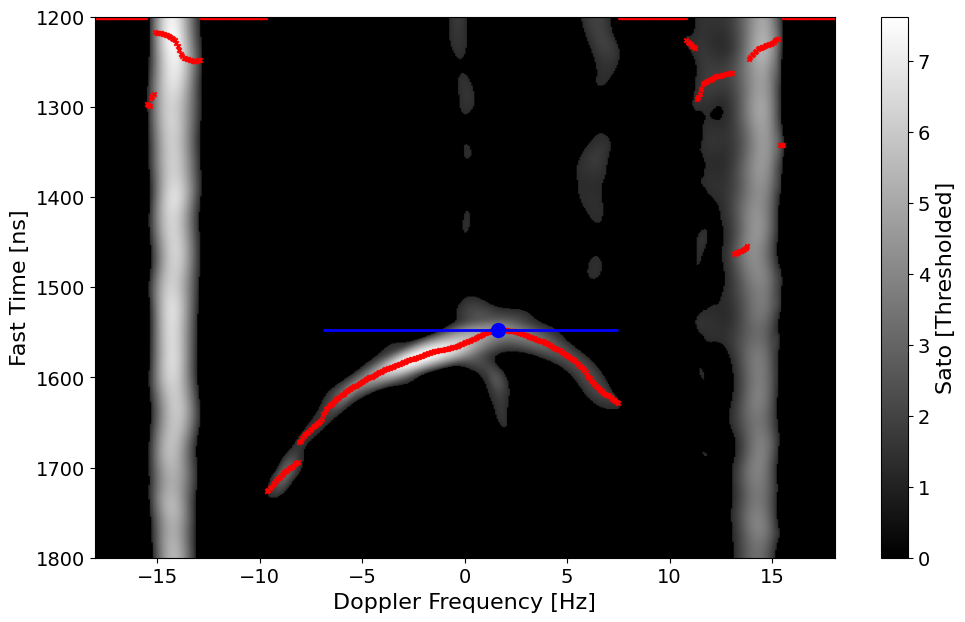

In [218]:
x_sato, y_sato, sobel_thresholded = calc_doppler_ridge(freq, data_fft, start_y, end_y)
right, left, x_at_max, y_at_max = calc_width_and_max(x_sato, y_sato)
ridge_params = {'right':right, 'left':left, 'x_at_max':x_at_max, 'y_at_max':y_at_max}
plot_doppler_ridge(freq, data_fft, start_y, end_y, ridge_params)

[[-40.133125 -22.676998 -34.963997 ... -26.830969 -30.278027 -26.274189]
 [-35.12069  -22.54496  -32.396675 ... -25.037868 -31.167446 -26.375439]
 [-33.711113 -23.464767 -29.862103 ... -24.528423 -31.778603 -26.89805 ]
 ...
 [-31.722029 -49.969555 -26.127739 ... -25.35301  -39.49334  -28.228148]
 [-31.32865  -40.134415 -27.388697 ... -24.854744 -36.16806  -29.676903]
 [-30.816862 -38.02445  -29.169016 ... -24.936962 -33.731224 -31.623678]]


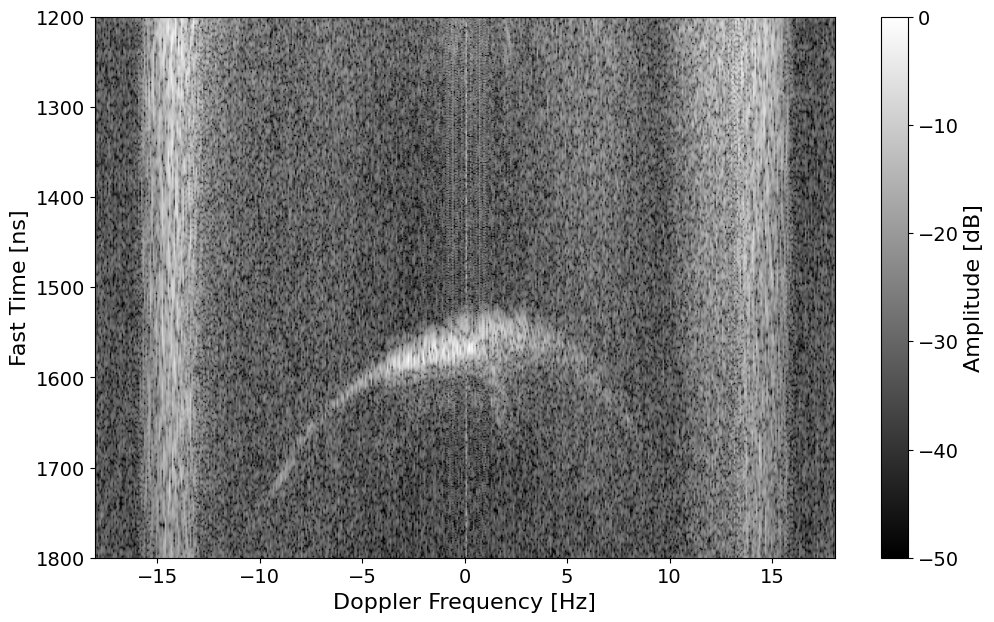

In [193]:
plot_doppler_spectrum(freq, data_fft, start_y, end_y)

In [295]:
# Loop over radargrams and compute width/max

plotting_dict = {'x_centers':[], 'y_centers':[],'ridge_params_list':[]}
for radargram in utig_radargrams[:]:
    print(radargram.transect_id)
    dat = radargram['bxds2'].compute().astype(np.float32) # bdxs2 is the low gain
    # Hilbert along fast_time axis
    analytic = hilbert(dat, axis=1)
    data = analytic.T

    x_at = radargram['distance'].compute().values  # meters
    
    dx = np.median(np.diff(x_at))
    win_m = 1000.0     # window length [m]
    ovlp_m = 250.0     # overlap [m]
    win_n = int(win_m / dx)
    step_n = int((win_m - ovlp_m) / dx)

    dt_slow = np.median(np.diff(
        (radargram['time'] - radargram['time'][0])
        .astype('timedelta64[ns]')
        .astype(np.float64)
        .compute()
    )) * 1e-9

    freq = np.fft.fftshift(
        np.fft.fftfreq(win_n, d=dt_slow)
    )

    start_y = 1200
    end_y = 1800
    data_for_plot = data[start_y:end_y:,:]
    dist_at = radargram['distance'].compute().values  # meters
    dist_at = dist_at[:]
    x_at = radargram['x'].compute().values  # meters
    x_at = x_at[:]
    y_at = radargram['y'].compute().values  # meters
    y_at = y_at[:]

    data = data_for_plot - np.mean(data_for_plot, axis=0, keepdims=True)
    window = hann(win_n)

    doppler_cubes = []     # list of [range, doppler]
    x_centers = []         # along-track center positions, x
    y_centers = []         # along-track center positions, y

    for start in range(0, data.shape[1] - win_n + 1, step_n):
        stop = start + win_n


        # Extract slow-time window
        data_win = data[:, start:stop]

        # Apply slow-time window
        data_win = data_win * window[None, :]

        # Doppler FFT
        fft_win = np.fft.fftshift(
            np.fft.fft(data_win, axis=1),
            axes=1
        )

        doppler_cubes.append(fft_win)

        # Store center along-track distance
        x_centers.append(np.mean(x_at[start:stop]))
        y_centers.append(np.mean(y_at[start:stop]))


    # start_y, end_y defined, same for all cubes
    # doppler_db is a list of data_fft
    # freq is also above and same for all cubes
    
    ridge_params_list = []
    for cube in doppler_cubes[:]:
        # Plot spectrum
        #plot_doppler_spectrum(freq, cube, start_y, end_y)
        
        x_sato, y_sato, sobel_thresholded = calc_doppler_ridge(freq, cube, start_y, end_y)
        right, left, x_at_max, y_at_max = calc_width_and_max(x_sato, y_sato)
        ridge_params = {'right':right, 'left':left, 'x_at_max':x_at_max, 'y_at_max':y_at_max}
        ridge_params_list.append(ridge_params)
        
        # Plot ridge choosing diagram
        #plot_doppler_ridge(freq, cube, start_y, end_y, ridge_params)

    
    # Store as array of arrays: 1st layer length = radargrams, 2nd layer length = windows per radargram
    plotting_dict['x_centers'].append(x_centers)
    plotting_dict['y_centers'].append(y_centers)
    plotting_dict['ridge_params_list'].append(ridge_params_list)



    

D2DG/IBH0e/X10a
D2DG/IBH0e/X11a
D2DG/IBH0e/X12a
D2DG/IBH0e/X13a
D2DG/IBH0e/X14a
D2DG/IBH0e/X15a
D2DG/IBH0e/X17a
D2DG/IBH0e/X18a
D2DG/IBH0e/X19a
D2DG/IBH0e/X20a
D2DG/IBH0e/X21a
D2DG/IBH0e/X21b
D2DG/IBH0e/X22a
D2DG/IBH0e/X23a
D2DG/IBH0e/X24a
D2DG/IBH0e/X25a
D2DG/IBH0e/X26a
D2DG/IBH0e/X27a
D2DG/IBH0e/X27b
D2DG/IBH0e/X28a
D2DG/IBH0e/X29a
D2DG/IBH0e/X30a
D2DG/IBH0e/X31a
D2DG/IBH0e/X32a
D2DG/IBH0e/X33a
D2DG/IBH0e/X34a
D2DG/IBH0e/X35a
D2DG/IBH0e/X37a
D2DG/IBH0g/Y22a
D2DG/IBH0g/Y23a
D2DG/IBH0g/Y24a
D2DG/IBH0g/Y25a
D2DG/IBH0g/Y26a
D2DG/IBH0g/Y27a
D2DG/IBH0g/Y28a
D2DG/IBH0g/Y29a
D2DG/IBH0g/Y30a
D2DG/IBH0g/Y31a
D2DG/IBH0g/Y32a
D2DG/IBH0g/Y33a
D2DG/IBH0g/Y34a
D2DG/IBH0g/Y35a


In [310]:
# Set up plan view plotting function
def plot_radargram_planview_width(ax, radargrams, xs_lake, ys_lake):
    bbox = [650000,-1475000,680000,-1430000] #David_SGL2_full

    ax.patch.set_facecolor("none")
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])

    for x_center_list, y_center_list, plotting in zip(plotting_dict['x_centers'], plotting_dict['y_centers'], plotting_dict['ridge_params_list']):
        width = [rp['right'] - rp['left'] for rp in plotting]
        xmax = [rp['x_at_max'] for rp in plotting]
        cb = ax.scatter(x_center_list, y_center_list, c=width, cmap='viridis', s=30, zorder=4,vmin=0,vmax=25)

    for x, y in zip(xs_lake, ys_lake):
        ax.plot(x, y, color='black', linewidth=3, zorder=0)

    # Add colorbar
    k_cbar_anchor = (0,0)
    cbbox = inset_axes(ax, width=3,height=1,
                    bbox_to_anchor=k_cbar_anchor,
                    bbox_transform=ax.transAxes, loc="center left")
    [cbbox.spines[k].set_visible(False) for k in cbbox.spines]
    cbbox.tick_params(
        axis = 'both',
        left = False,
        top = False,
        right = False,
        bottom = False,
        labelleft = False,
        labeltop = False,
        labelright = False,
        labelbottom = False
    )
    cbbox.set_facecolor([0,0,0,0.9])

    cbaxes = inset_axes(cbbox, '92%', '20%', loc = 'center')
    cbar=fig.colorbar(cb,cax=cbaxes, orientation='horizontal',extend='max') #make colorbar
    cbar.outline.set_edgecolor('white')
    cbar.outline.set_linewidth(1)
    cbar.ax.tick_params(labelsize=14, color='white', labelcolor='white')
    cbar.set_label("Doppler Width [Hz]", fontsize=15, color='white')
    cbar.ax.xaxis.set_label_position('top')

    cbar.ax.minorticks_on()

    ax.set_xlim(bbox[0],bbox[2])
    ax.set_ylim(bbox[1],bbox[3])


# Set up plan view plotting function
def plot_radargram_planview_offset(ax, radargrams, xs_lake, ys_lake):
    bbox = [650000,-1475000,680000,-1430000] #David_SGL2_full

    ax.patch.set_facecolor("none")
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])

    for x_center_list, y_center_list, plotting in zip(plotting_dict['x_centers'], plotting_dict['y_centers'], plotting_dict['ridge_params_list']):
        width = [rp['right'] - rp['left'] for rp in plotting]
        xmax = [rp['x_at_max'] for rp in plotting]
        cb = ax.scatter(x_center_list, y_center_list, c=xmax, cmap='magma', s=30, zorder=4,vmin=-5,vmax=5)

    for x, y in zip(xs_lake, ys_lake):
        ax.plot(x, y, color='black', linewidth=3, zorder=0)

    # Add colorbar
    k_cbar_anchor = (0,0)
    cbbox = inset_axes(ax, width=3,height=1,
                    bbox_to_anchor=k_cbar_anchor,
                    bbox_transform=ax.transAxes, loc="center left")
    [cbbox.spines[k].set_visible(False) for k in cbbox.spines]
    cbbox.tick_params(
        axis = 'both',
        left = False,
        top = False,
        right = False,
        bottom = False,
        labelleft = False,
        labeltop = False,
        labelright = False,
        labelbottom = False
    )
    cbbox.set_facecolor([0,0,0,0.9])

    cbaxes = inset_axes(cbbox, '92%', '20%', loc = 'center')
    cbar=fig.colorbar(cb,cax=cbaxes, orientation='horizontal',extend='both') #make colorbar
    cbar.outline.set_edgecolor('white')
    cbar.outline.set_linewidth(1)
    cbar.ax.tick_params(labelsize=14, color='white', labelcolor='white')
    cbar.set_label("Doppler Offset [Hz]", fontsize=15, color='white')
    cbar.ax.xaxis.set_label_position('top')

    cbar.ax.minorticks_on()

    ax.set_xlim(bbox[0],bbox[2])
    ax.set_ylim(bbox[1],bbox[3])




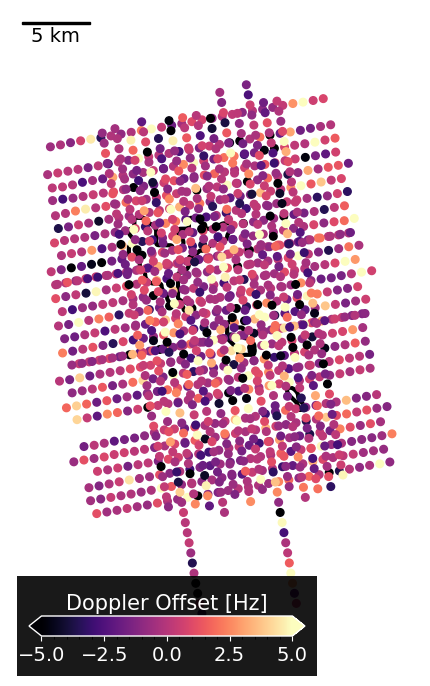

In [312]:
# Plot plan view comparison
ps71_projection = ccrs.Stereographic(central_latitude=-90, central_longitude=0, true_scale_latitude=-71)
fig, ax = plt.subplots(figsize=(8,8), subplot_kw={'projection': ps71_projection})

#plot_radargram_planview_width(ax, plotting_dict, xs_lake, ys_lake)
plot_radargram_planview_offset(ax, plotting_dict, xs_lake, ys_lake)
#plot_radargram_planview(ax, utig_radargrams, xs_lake, ys_lake)
scalebar = AnchoredSizeBar(ax.transData, 5000, '5 km', 'upper left', 
                           pad=0.5, color='black', frameon=False, size_vertical=200, fontproperties={'size': 14})
ax.add_artist(scalebar)
